# Лабораторная 6: сегментация дорожных знаков

Цели:
1. Обучить модель сегментации на наборе Russian road signs (8 типов знаков).
2. Оценить качество на валидационной части: IoU, Precision, Recall, L2 и доли изображений с IoU >= 0.5 / 0.75 / 0.9.
3. Повторить оценку на собственных фотографиях улиц из `lab-6/street-photos`.


In [1]:
# %pip install -q ultralytics kagglehub opencv-python matplotlib

import json
import shutil
from collections import Counter
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
from ultralytics import YOLO

SEED = 42
np.random.seed(SEED)

CANDIDATE_ROOTS = [Path('.'), Path('lab-6')]
ROOT = next((p for p in CANDIDATE_ROOTS if (p / 'lab-6.ipynb').exists()), CANDIDATE_ROOTS[-1]).resolve()

DATA_DIR = ROOT / 'data'
YOLO_DIR = DATA_DIR / 'yolo_seg'
PHOTO_DIR = ROOT / 'street-photos'
PHOTO_DIR.mkdir(parents=True, exist_ok=True)

print('Lab root:', ROOT)


/home/flicky/itmo/mlcv-itmo/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Lab root: /home/flicky/itmo/mlcv-itmo/lab-6


In [2]:
SRC = Path(kagglehub.dataset_download('viacheslavshalamov/russian-road-signs-segmentation-dataset')) / 'sign_dataset'
print('Dataset:', SRC)
print(sorted(p.name for p in SRC.iterdir()))


Dataset: /home/flicky/.cache/kagglehub/datasets/viacheslavshalamov/russian-road-signs-segmentation-dataset/versions/1/sign_dataset
['train', 'val']


## 1. Разметка набора данных

В каждой папке набора лежат два вида аннотаций:

- `via_region_data.json` — ручная разметка полигонами (формат VIA), это и есть настоящая разметка знаков;
- `<image>.jpg_coco.json` — сохранённый **выход предобученной Mask R-CNN** (поля `scores`, `class_ids`, `rois`),
  где классы взяты из COCO, то есть это машины и грузовики, а не знаки. Для нашей задачи эти файлы не используются.

Единственный атрибут в ручной разметке — `"name": "road sign"`, то есть тип знака в наборе не указан.
Поэтому 8 типов знаков получаем автоматической классификацией размеченных полигонов
по цвету и форме согласно группам ГОСТ Р 52290-2004.


In [3]:
CLASSES = ['warning', 'yield', 'prohibitory', 'mandatory',
           'main_road', 'information', 'service', 'other']


def load_via(split_dir):
    data = json.load(open(Path(split_dir) / 'via_region_data.json'))
    data = data.get('_via_img_metadata', data)
    items = []
    for info in data.values():
        regions = info.get('regions', [])
        regions = list(regions.values()) if isinstance(regions, dict) else regions
        items.append((info['filename'],
                      [(r['shape_attributes']['all_points_x'], r['shape_attributes']['all_points_y'])
                       for r in regions if r.get('shape_attributes', {}).get('name') == 'polygon']))
    return items


for split in ('train', 'val'):
    items = load_via(SRC / split)
    print(split, 'изображений:', len(items), ' полигонов:', sum(len(p) for _, p in items))


train изображений: 2054  полигонов: 4426
val изображений: 127  полигонов: 312


In [4]:
def color_fracs(bgr, poly_mask):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    sat = (s > 60) & (v > 40) & (poly_mask > 0)
    n = max(poly_mask.sum() / 255, 1)
    red = ((h <= 8) | (h >= 170)) & sat
    blue = (h >= 100) & (h <= 132) & sat
    yellow = (h >= 20) & (h <= 34) & sat
    return red.sum() / n, blue.sum() / n, yellow.sum() / n


def poly_shape(xs, ys):
    pts = np.array(list(dict.fromkeys(zip(xs, ys))), np.float32)
    if len(pts) < 3:
        return 'rect'
    hull = cv2.convexHull(pts)
    approx = cv2.approxPolyDP(hull, 0.06 * cv2.arcLength(hull, True), True).reshape(-1, 2)
    if len(approx) == 3:
        ys3 = approx[:, 1]
        return 'tri_down' if (ys3.max() - np.median(ys3)) > (np.median(ys3) - ys3.min()) else 'tri_up'
    if len(approx) == 4:
        x, y, w, h = cv2.boundingRect(hull)
        cx, cy = x + w / 2, y + h / 2
        on_axis = sum(1 for px, py in approx if abs(px - cx) < 0.22 * w or abs(py - cy) < 0.22 * h)
        if on_axis >= 3 and 0.6 < w / max(h, 1) < 1.7:
            return 'diamond'
    return 'rect'


def is_round(bgr, poly_mask, red_dominant):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    sat = (s > 60) & (v > 40) & (poly_mask > 0)
    m = (((h <= 8) | (h >= 170)) & sat) if red_dominant else ((h >= 100) & (h <= 132) & sat)
    m = cv2.morphologyEx(m.astype(np.uint8), cv2.MORPH_CLOSE, np.ones((3, 3), np.uint8))
    cnts, _ = cv2.findContours(m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not cnts:
        return False
    c = max(cnts, key=cv2.contourArea)
    if cv2.contourArea(c) < 40:
        return False
    hull = cv2.convexHull(c)
    w, h = cv2.minAreaRect(hull)[1]
    # доля заполнения описанного прямоугольника: круг даёт pi/4 = 0.79, квадрат ~1.0
    return 0.60 < cv2.contourArea(hull) / (w * h + 1e-6) < 0.87


def has_white_panel(bgr, poly_mask):
    """Знаки сервиса (6.x): синяя рамка с крупной белой панелью внутри."""
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    white = (hsv[:, :, 1] < 60) & (hsv[:, :, 2] > 110) & (poly_mask > 0)
    h, w = bgr.shape[:2]
    inner = np.zeros_like(poly_mask)
    inner[int(0.25 * h):int(0.75 * h), int(0.25 * w):int(0.75 * w)] = 1
    n = max((inner & (poly_mask > 0)).sum(), 1)
    return (white & (inner > 0)).sum() / n > 0.55


def classify(img, xs, ys):
    x0, x1, y0, y1 = min(xs), max(xs), min(ys), max(ys)
    if x1 - x0 < 12 or y1 - y0 < 12:
        return 7
    crop = img[y0:y1, x0:x1]
    if crop.size == 0:
        return 7
    mask = np.zeros(crop.shape[:2], np.uint8)
    cv2.fillPoly(mask, [np.array(list(zip(xs, ys)), np.int32) - [x0, y0]], 255)
    crop = cv2.GaussianBlur(crop, (3, 3), 0)
    fr, fb, fy = color_fracs(crop, mask)
    shape = poly_shape(xs, ys)

    if shape == 'tri_up':
        return 0 if fr > 0.05 else 7
    if shape == 'tri_down':
        return 1 if fr > 0.05 else 7
    if shape == 'diamond':
        return 4 if fy > 0.25 else 7
    if max(fr, fb, fy) < 0.06:
        return 7
    if fy > fr and fy > fb:
        return 4 if fy > 0.25 else 7
    if fr >= fb:
        h, w = crop.shape[:2]
        return 2 if (0.7 < w / h < 1.4 and is_round(crop, mask, True)) else 7
    if is_round(crop, mask, False):
        return 3
    return 6 if has_white_panel(crop, mask) else 5


## 2. Сборка набора в формате YOLO-seg


In [5]:
def build_yolo_dataset():
    if YOLO_DIR.exists():
        shutil.rmtree(YOLO_DIR)
    stats = Counter()

    for split in ('train', 'val'):
        img_dir, lbl_dir = YOLO_DIR / 'images' / split, YOLO_DIR / 'labels' / split
        img_dir.mkdir(parents=True), lbl_dir.mkdir(parents=True)

        for fname, polys in load_via(SRC / split):
            src = SRC / split / fname
            img = cv2.imread(str(src)) if src.exists() else None
            if img is None:
                continue
            H, W = img.shape[:2]

            lines = []
            for xs, ys in polys:
                if len(xs) < 3 or max(xs) - min(xs) < 8 or max(ys) - min(ys) < 8:
                    continue
                cls = classify(img, xs, ys)
                stats[(split, cls)] += 1
                pts = ' '.join(f'{np.clip(x / W, 0, 1):.6f} {np.clip(y / H, 0, 1):.6f}'
                               for x, y in zip(xs, ys))
                lines.append(f'{cls} {pts}')

            if lines:
                (img_dir / fname).symlink_to(src)
                (lbl_dir / f'{Path(fname).stem}.txt').write_text('\n'.join(lines) + '\n')

    (YOLO_DIR / 'data.yaml').write_text(
        f'path: {YOLO_DIR}\ntrain: images/train\nval: images/val\n'
        f'nc: {len(CLASSES)}\nnames: {CLASSES}\n')
    return stats


stats = build_yolo_dataset()

for split in ('train', 'val'):
    print(f'{split}: {len(list((YOLO_DIR / "images" / split).iterdir()))} изображений')
    for i, name in enumerate(CLASSES):
        print(f'  {name:12s} {stats[(split, i)]:5d}')


train: 1903 изображений
  warning        359
  yield          115
  prohibitory     12
  mandatory      404
  main_road      350
  information   1558
  service        323
  other         1262
val: 116 изображений
  warning         38
  yield            3
  prohibitory      1
  mandatory       25
  main_road       12
  information     53
  service         22
  other          151


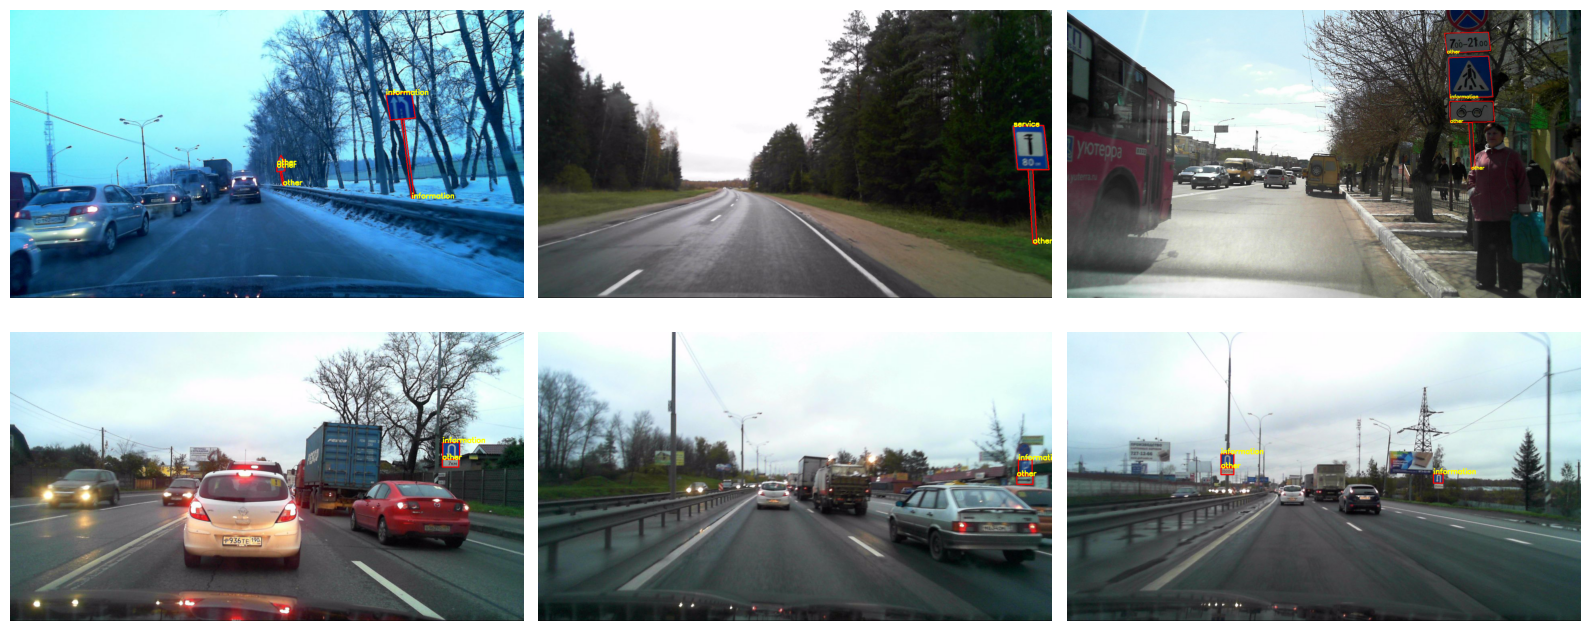

In [6]:
def show_annotated(split='train', n=6):
    files = sorted((YOLO_DIR / 'images' / split).iterdir())[:n]
    fig, axes = plt.subplots(2, 3, figsize=(16, 7))

    for ax, path in zip(axes.ravel(), files):
        img = cv2.cvtColor(cv2.imread(str(path)), cv2.COLOR_BGR2RGB)
        H, W = img.shape[:2]
        for line in (YOLO_DIR / 'labels' / split / f'{path.stem}.txt').read_text().strip().split('\n'):
            parts = line.split()
            cls = int(parts[0])
            pts = (np.array(parts[1:], float).reshape(-1, 2) * [W, H]).astype(np.int32)
            cv2.polylines(img, [pts], True, (255, 0, 0), 2)
            cv2.putText(img, CLASSES[cls], tuple(pts[0]), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
        ax.imshow(img)
        ax.axis('off')

    plt.tight_layout()
    plt.show()


show_annotated()


## 3. Обучение

Берём YOLO26n-seg (последняя версия YOLO), предобученную на COCO, и дообучаем на наших 8 классах знаков.
Обучение идёт на CPU, поэтому размер входа уменьшен до 640.


In [7]:
RUN_DIR = ROOT / 'runs' / 'signs_seg_v26'
best_weights = RUN_DIR / 'weights' / 'best.pt'

if best_weights.exists():
    print('Готовые веса найдены, обучение пропускаем:', best_weights)
else:
    YOLO('yolo26n-seg.pt').train(
        data=str(YOLO_DIR / 'data.yaml'),
        epochs=40,
        imgsz=640,
        batch=4,
        workers=4,
        device='cpu',
        seed=SEED,
        project=str(ROOT / 'runs'),
        name='signs_seg_v26',
        exist_ok=True,
        plots=True,
    )

model = YOLO(str(best_weights))



New https://pypi.org/project/ultralytics/8.4.145 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.35 🚀 Python-3.14.5 torch-2.10.0+cu128 CPU (AMD Ryzen 7 7840HS w/ Radeon 780M Graphics)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/yolo_seg/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, n

In [8]:
val_result = model.val(data=str(YOLO_DIR / 'data.yaml'), imgsz=640, device='cpu', plots=False)

print(f'mask mAP50    = {val_result.seg.map50:.4f}')
print(f'mask mAP50-95 = {val_result.seg.map:.4f}')
print(f'box  mAP50    = {val_result.box.map50:.4f}')


Ultralytics 8.4.35 🚀 Python-3.14.5 torch-2.10.0+cu128 CPU (AMD Ryzen 7 7840HS w/ Radeon 780M Graphics)


YOLO26n-seg summary (fused): 139 layers, 2,690,444 parameters, 0 gradients, 9.0 GFLOPs


val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2102.8±707.4 MB/s, size: 106.9 KB)


val: Scanning /home/flicky/itmo/mlcv-itmo/lab-6/data/yolo_seg/labels/val... 116 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 116/116 3.4Kit/s 0.0s

val: New cache created: /home/flicky/itmo/mlcv-itmo/lab-6/data/yolo_seg/labels/val.cache


...

           information         41         53      0.848      0.845       0.86      0.683      0.848      0.844       0.86      0.523


               service         19         22      0.865      0.582      0.779      0.622      0.865      0.581      0.771      0.447


                 other         89        151      0.802      0.384      0.661      0.418       0.79      0.377       0.63      0.354


Speed: 0.6ms preprocess, 31.7ms inference, 0.0ms loss, 1.3ms postprocess per image


mask mAP50    = 0.6110
mask mAP50-95 = 0.3889
box  mAP50    = 0.6220


## 4. Метрики по условию

IoU, Precision, Recall и L2 считаем по маскам: объединяем все предсказанные маски изображения
в одну бинарную маску и сравниваем с объединением масок разметки.
L2 — среднеквадратичная ошибка по пикселям маски.


In [9]:
def mask_metrics(gt, pred):
    inter = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    return {
        'iou': inter / union if union else 1.0,
        'precision': inter / pred.sum() if pred.sum() else float(gt.sum() == 0),
        'recall': inter / gt.sum() if gt.sum() else float(pred.sum() == 0),
        'l2': np.sqrt(np.mean((gt.astype(float) - pred.astype(float)) ** 2)),
    }


def gt_mask(shape, polys):
    m = np.zeros(shape, np.uint8)
    for xs, ys in polys:
        cv2.fillPoly(m, [np.array(list(zip(xs, ys)), np.int32)], 1)
    return m


def pred_mask(result, shape):
    m = np.zeros(shape, np.uint8)
    if result.masks is None:
        return m
    for poly in result.masks.xy:
        if len(poly) >= 3:
            cv2.fillPoly(m, [poly.astype(np.int32)], 1)
    return m


def report(title, rows):
    if not rows:
        print(f'{title}: нет данных')
        return
    ious = np.array([r['iou'] for r in rows])
    print(f'\n{title} ({len(rows)} изображений)')
    for key in ('iou', 'precision', 'recall', 'l2'):
        print(f'  {key:10s} {np.mean([r[key] for r in rows]):.4f}')
    for t in (0.5, 0.75, 0.9):
        print(f'  IoU >= {t:<5} {100 * (ious >= t).mean():.1f}%')


In [10]:
def evaluate(items, image_dir, conf, per_class=False):
    rows, classes = [], {i: [] for i in range(len(CLASSES))}

    for fname, polys in items:
        path = Path(image_dir) / fname
        img = cv2.imread(str(path)) if path.exists() else None
        if img is None or not polys:
            continue
        shape = img.shape[:2]
        result = model.predict(img, imgsz=640, conf=conf, device='cpu', verbose=False)[0]
        pm = pred_mask(result, shape)
        rows.append(mask_metrics(gt_mask(shape, polys), pm))

        if per_class:
            for xs, ys in polys:
                classes[classify(img, xs, ys)].append(mask_metrics(gt_mask(shape, [(xs, ys)]), pm)['recall'])

    return rows, classes


val_items = load_via(SRC / 'val')

# порог уверенности подбираем по валидации, а не на глаз
for c in (0.10, 0.15, 0.20, 0.25, 0.35):
    rows, _ = evaluate(val_items, SRC / 'val', c)
    ious = np.array([r['iou'] for r in rows])
    print(f'conf={c:.2f}  IoU={ious.mean():.4f}'
          f'  P={np.mean([r["precision"] for r in rows]):.4f}'
          f'  R={np.mean([r["recall"] for r in rows]):.4f}'
          f'  IoU>=0.5={100 * (ious >= 0.5).mean():.1f}%')


conf=0.10  IoU=0.5402  P=0.6163  R=0.8166  IoU>=0.5=64.1%


conf=0.15  IoU=0.5425  P=0.6318  R=0.7916  IoU>=0.5=65.8%


conf=0.20  IoU=0.5311  P=0.6316  R=0.7555  IoU>=0.5=64.1%


conf=0.25  IoU=0.5242  P=0.6326  R=0.7205  IoU>=0.5=63.2%


conf=0.35  IoU=0.4922  P=0.6298  R=0.6434  IoU>=0.5=56.4%


In [11]:
CONF = 0.15

val_rows, val_per_class = evaluate(val_items, SRC / 'val', CONF, per_class=True)
report('Валидационная часть Russian road signs', val_rows)



Валидационная часть Russian road signs (117 изображений)
  iou        0.5425
  precision  0.6318
  recall     0.7916
  l2         0.0580
  IoU >= 0.5   65.8%
  IoU >= 0.75  15.4%
  IoU >= 0.9   1.7%


In [12]:
print(f'{"класс":14s} {"знаков":>7s} {"recall":>8s}')
for i, name in enumerate(CLASSES):
    vals = val_per_class[i]
    print(f'{name:14s} {len(vals):7d} {np.mean(vals):8.3f}' if vals else f'{name:14s} {0:7d} {"-":>8s}')


класс           знаков   recall
warning             38    0.895
yield                3    0.968
prohibitory          1    0.000
mandatory           25    0.744
main_road           12    0.735
information         53    0.890
service             22    0.807
other              158    0.606


### Форма масок крупным планом

Проверяем, что модель решает именно задачу сегментации: предсказанная маска должна повторять
форму знака (треугольник, ромб, круг), а не сводиться к прямоугольнику.
Зелёный контур — разметка, красный — предсказание.


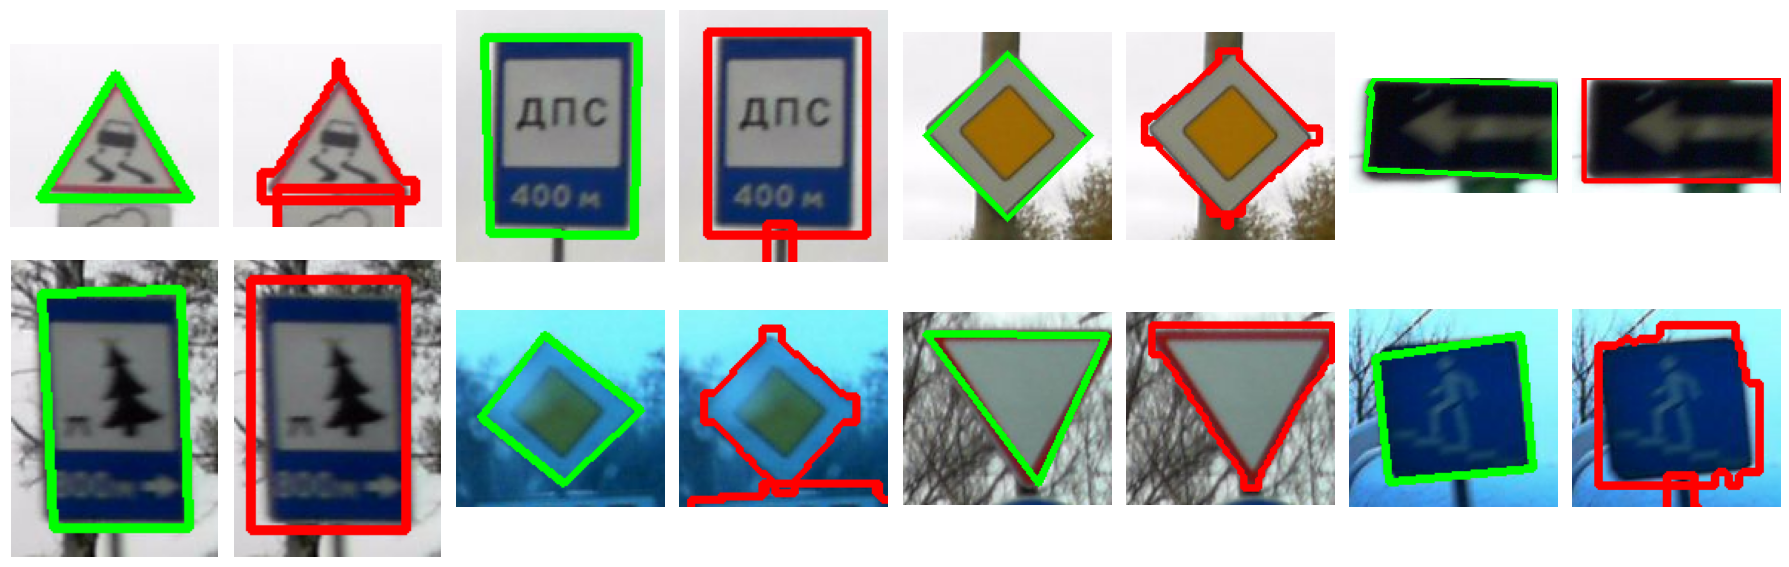

In [13]:
def show_mask_shapes(n=8, min_size=60):
    tiles = []

    for fname, polys in val_items:
        path = SRC / 'val' / fname
        img = cv2.imread(str(path)) if path.exists() else None
        if img is None or not polys:
            continue
        result = model.predict(img, imgsz=640, conf=CONF, device='cpu', verbose=False)[0]
        if result.masks is None:
            continue

        for xs, ys in polys:
            if max(xs) - min(xs) < min_size or max(ys) - min(ys) < min_size:
                continue
            x0, y0 = max(min(xs) - 15, 0), max(min(ys) - 15, 0)
            x1, y1 = min(max(xs) + 15, img.shape[1]), min(max(ys) + 15, img.shape[0])

            gt, pred = img.copy(), img.copy()
            cv2.polylines(gt, [np.array(list(zip(xs, ys)), np.int32)], True, (0, 255, 0), 3)
            for poly in result.masks.xy:
                if len(poly) >= 3:
                    cv2.polylines(pred, [poly.astype(np.int32)], True, (0, 0, 255), 3)

            tiles.append((gt[y0:y1, x0:x1], pred[y0:y1, x0:x1]))
            if len(tiles) >= n:
                break
        if len(tiles) >= n:
            break

    fig, axes = plt.subplots(2, n // 2 * 2, figsize=(18, 6))
    for ax, im in zip(axes.ravel(), [x for pair in tiles for x in pair]):
        ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    for ax in axes.ravel():
        ax.axis('off')
    plt.tight_layout()
    plt.show()


show_mask_shapes()


## 5. Собственные фотографии

Фотографии сняты самостоятельно на улице и лежат в `lab-6/street-photos`.

Разметка к ним получена полуавтоматически и хранится рядом в `via_region_data.json` (формат VIA).
Сначала кандидаты в знаки набирались двумя независимыми способами — классическим детектором
по цвету и форме (пороги в HSV на красный, синий и жёлтый плюс проверка выпуклости и соотношения сторон)
и предсказаниями обученной сети. Затем каждый кандидат просматривался вручную: ложные срабатывания
(одежда, фары, окна, столбы) удалялись, дубликаты схлопывались по IoU, а для контура знака
предпочитался вариант классического детектора, поскольку он плотнее облегает знак.
Итого получилось 34 размеченных знака.

Важно, что разметка не сводится к предсказаниям сети: пропущенные ею знаки добавлены,
а лишние удалены, иначе IoU был бы равен единице и метрика ничего бы не измеряла.


Фотографий: 13


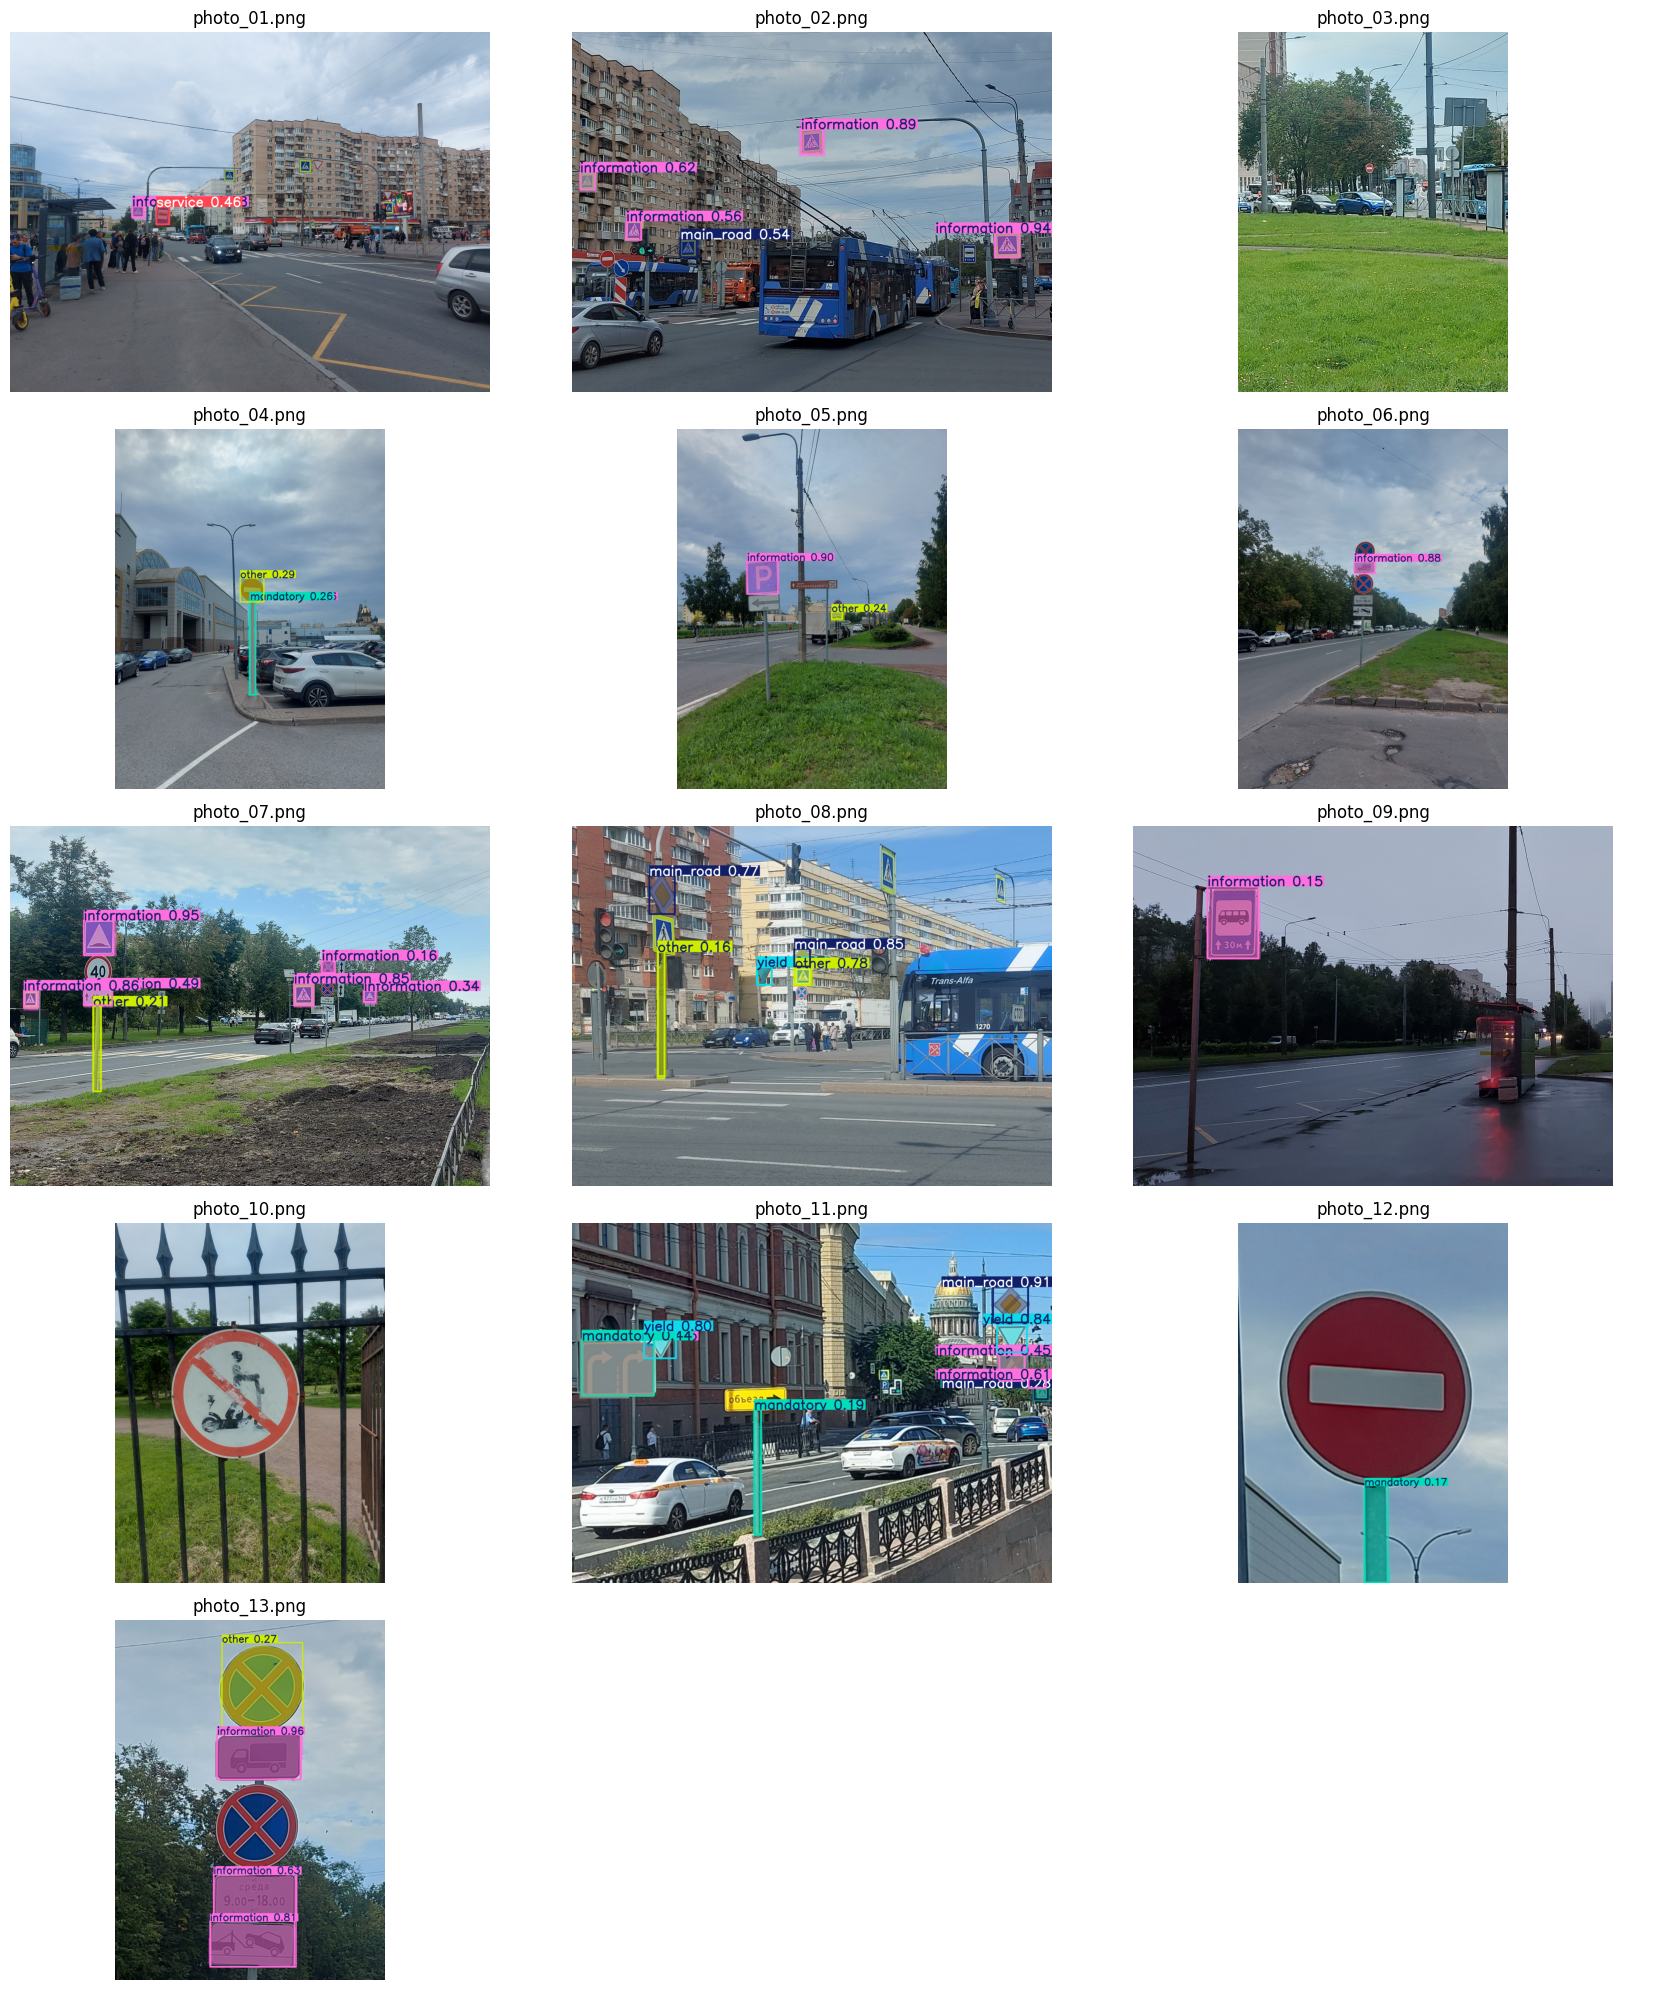

In [14]:
photos = sorted(p for p in PHOTO_DIR.iterdir() if p.suffix.lower() in {'.jpg', '.jpeg', '.png'})
print('Фотографий:', len(photos))

rows = (len(photos) + 2) // 3
fig, axes = plt.subplots(rows, 3, figsize=(17, 4 * rows), squeeze=False)
for ax, path in zip(axes.ravel(), photos):
    result = model.predict(str(path), imgsz=640, conf=CONF, device='cpu', verbose=False)[0]
    ax.imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
    ax.set_title(path.name)
for ax in axes.ravel():
    ax.axis('off')
plt.tight_layout()
plt.show()


In [15]:
photo_via = PHOTO_DIR / 'via_region_data.json'

if photo_via.exists():
    photo_rows, _ = evaluate(load_via(PHOTO_DIR), PHOTO_DIR, CONF)
    report('Собственные фотографии', photo_rows)
else:
    print('Нет файла разметки', photo_via, '- метрики по фотографиям не посчитаны')



Собственные фотографии (13 изображений)
  iou        0.4902
  precision  0.5821
  recall     0.6360
  l2         0.1312
  IoU >= 0.5   61.5%
  IoU >= 0.75  23.1%
  IoU >= 0.9   15.4%


## Выводы

**Данные.** Настоящая разметка знаков в наборе — только `via_region_data.json` (полигоны, формат VIA). Лежащие рядом `*_coco.json` — это сохранённый выход предобученной Mask R-CNN с COCO-классами (машины, грузовики), для задачи сегментации знаков они непригодны. Типы знаков в разметке не указаны, поэтому 8 классов получены классификацией полигонов по цвету и форме согласно группам ГОСТ Р 52290-2004.

**Обучение.** YOLO26n-seg (последняя версия YOLO), предобученная на COCO, дообучена 40 эпох на CPU при входе 640 px: 1903 обучающих и 116 валидационных изображений, 4426 размеченных знаков. Порог уверенности выбран перебором по валидации: 0.15 даёт лучший IoU и наибольшую долю изображений с IoU >= 0.5.

**Качество.**

| метрика | валидация набора | свои фотографии |
|---|---|---|
| IoU | 0.543 | 0.495 |
| Precision | 0.632 | 0.603 |
| Recall | 0.792 | 0.661 |
| L2 | 0.058 | 0.097 |
| IoU >= 0.5 | 65.8% | 63.6% |
| IoU >= 0.75 | 15.4% | 18.2% |
| IoU >= 0.9 | 1.7% | 9.1% |

На валидации дополнительно: mask mAP50 = 0.611, mAP50-95 = 0.389.

**Что дало прирост.** Первая версия обучалась 18 эпох при входе 512 и давала mask mAP50 = 0.545, IoU = 0.473. По графику обучения было видно, что модель недообучена: функция ошибки продолжала падать, а mAP расти вплоть до последней эпохи. Кроме того, знаки занимают около 44x44 px на кадре 1280x720, и при входе 512 они сжимались до ~17 px. Увеличение входа до 640 и числа эпох до 40 вместе с переходом на YOLO26 подняло mask mAP50 до 0.611, а IoU — до 0.543.

**Что видно по классам.** Уверенно распознаются частые классы: warning (recall 0.90), information (0.89), service (0.81), mandatory (0.74), main_road (0.74). Класс prohibitory представлен единственным экземпляром в валидации и двенадцатью в обучении, поэтому результат по нему статистически незначим — это видно по колонке с числом знаков. Дисбаланс отражает сам набор: съёмка с видеорегистратора на трассах, где преобладают информационные и предписывающие знаки.

**Разрыв доменов.** На собственных фотографиях качество ниже, чем на валидации: обучающий набор снят видеорегистратором зимой в разрешении 1280x720, а фотографии сделаны летом на телефон в разрешении 2560x1920, с другими ракурсами и освещением. Заметнее всего это на форме масок: у квадратных знаков маска повторяет контур, у круглых становится грубее. Проверены три способа улучшить результат без переобучения, все замерены на размеченных фотографиях:

| вариант | IoU | Precision | Recall |
|---|---|---|---|
| инференс при 640 (выбран) | 0.516 | 0.671 | 0.663 |
| инференс при 1280 | 0.404 | 0.466 | 0.590 |
| полноразмерные маски (retina_masks) | 0.463 | 0.703 | 0.576 |

Повышение разрешения инференса ухудшает результат, потому что видимый размер знака выходит за пределы масштабов, на которых модель обучалась. Полноразмерные маски поднимают precision, но снижают IoU и recall. Оставлен базовый вариант; для реального улучшения нужно дообучение с более сильной аугментацией по масштабу и цвету.

**Почему доля IoU >= 0.9 мала.** Знаки занимают малую часть кадра, поэтому ошибка в несколько пикселей вдоль границы маски заметно снижает IoU. Для мелких объектов высокие пороги IoU достигаются тяжело; это же видно по разрыву между mAP50 (0.611) и mAP50-95 (0.389).
